---
## 1. Theory & Background
---

### 1.1 Adsorption Energy — Formula and Physical Meaning

The adsorption energy quantifies how strongly H₂ binds to the surface compared to being a free molecule in the gas phase [1,2]:

$$E_{\text{ads}} = E(\text{slab} + \text{H}_2) - E(\text{clean slab}) - E(\text{H}_2^{\text{gas}})$$

**Sign convention:**
- $E_{\text{ads}} < 0$ (negative): exothermic adsorption — H₂ **gains** energy by binding to the surface. The more negative, the stronger the binding.
- $E_{\text{ads}} > 0$ (positive): endothermic — H₂ does NOT spontaneously adsorb. This rarely occurs for transition metal surfaces.
- $E_{\text{ads}} = 0$: no interaction between H₂ and surface.

**Physical interpretation:**  
$E_{\text{ads}}$ is the energy released when one H₂ molecule adsorbs from the gas phase onto the surface at the given site. It sets the depth of the potential energy well that H₂ must escape to desorb, and determines the starting geometry for the dissociation barrier calculation in Notebook 06.

**Typical values for Ni-based surfaces [3,4]:**

| Surface | E_ads (eV) | Binding type |
|---------|------------|-------------|
| Physisorption (weak) | −0.01 to −0.1 | van der Waals only |
| Chemisorption (strong) | −0.3 to −1.0 | Covalent/electronic interaction |
| Ni(111) hollow site | ~−0.5 to −0.7 | Chemisorption |

**Key references:** [1–4]

### 1.2 The Four Adsorption Sites on FCC(111)

The FCC(111) surface has four distinct high-symmetry adsorption sites [1,5,6]. These are the only sites that need to be tested — all other positions are equivalent to one of these by symmetry:


| Site | Description | Surface coordination | Subsurface atom? |
|------|-------------|---------------------|------------------|
| **Top (T)** | Directly above a surface atom | 1-fold | None |
| **Bridge (B)** | Between two adjacent surface atoms | 2-fold | None |
| **FCC Hollow (F)** | Above a 3-fold hollow with NO atom below in layer 2 | 3-fold | Layer 3 atom |
| **HCP Hollow (H)** | Above a 3-fold hollow WITH an atom below in layer 2 | 3-fold | Layer 2 atom |

**Why FCC and HCP hollows are different:**  
Both look like 3-fold hollows from above, but differ in what lies beneath. The FCC hollow has an atom in layer 3 directly below (continuing the ABCABC stacking). The HCP hollow has an atom in layer 2 directly below (the site would continue as ABAB if stacking were HCP). This difference in subsurface geometry changes the electronic interaction and adsorption energy [5,6].

**For Hastelloy N:**  
Because our surface contains Mo (one atom), we also test:
- **Top-Ni**: top site above a Ni atom
- **Top-Mo**: top site above the Mo atom

Mo and Ni have significantly different d-band centers, so their top-site adsorption energies will differ noticeably (see Section 1.4).

**Key references:** [1,5,6]

### 1.3 H₂ Placement: Height and Orientation

**Height above surface: 2.5 Å**  
We place the H₂ center of mass 2.5 Å above the top surface layer atom. This is the standard starting distance for H₂ adsorption on transition metal surfaces [3,4,7]. It is:
- Far enough that H₂ is not forced into a pre-dissociated configuration
- Close enough that the MACE potential can compute realistic interaction forces from the first minimization step
- Larger than the Ni-H equilibrium bond length (~1.7 Å) so we avoid artificially constraining the geometry

If placed too close (< 1.5 Å), H₂ may spontaneously dissociate during minimization and we would be computing dissociative adsorption energy rather than molecular adsorption energy. This is relevant for Notebook 06, not here.

**Orientation: parallel to surface (H₂ bond along x-axis)**  
Molecular H₂ approaching a metal surface prefers a flat-lying (parallel) orientation over an upright (perpendicular) orientation for most hollow and bridge sites [3,5,7]. We start all sites with H₂ parallel to the surface. The minimization will rotate H₂ to its true equilibrium orientation.

**H-H bond length: 0.741 Å**  
This is the experimental gas-phase H₂ bond length [8]. We use it as the starting geometry before any relaxation.

**Key references:** [3,4,5,7,8]

### 1.4 The d-Band Model — Why Mo Binds H₂ Differently Than Ni

The d-band model (Hammer-Nørskov) explains why different transition metal atoms on a surface bind adsorbates with different strengths [9,10]. The key insight is:

**The higher the d-band center (ε_d) relative to the Fermi level, the stronger the binding.**

When H₂ approaches a metal surface, its σ and σ* molecular orbitals hybridize with the metal d-band. The interaction has two contributions:
1. **Bonding states** (below Fermi level) — stabilize the adsorbate
2. **Antibonding states** — destabilize if filled (i.e., if they fall below the Fermi level)

A higher d-band center pushes antibonding states above the Fermi level → fewer filled antibonding states → stronger net binding.

**For Hastelloy N surface atoms [9,10,11]:**

| Element | d-band center (ε_d - E_F) | Expected H₂ binding |
|---------|---------------------------|---------------------|
| Mo | −1.3 eV (higher) | **Stronger** |
| Ni | −1.7 eV (lower) | Moderate |
| Cr | −2.0 eV | Weaker |

Therefore: **we expect the top-Mo site to show stronger (more negative) H₂ adsorption than top-Ni**. The hollow sites are generally the most stable due to 3-fold coordination.

**Key references:** [9,10,11]

### 1.5 H₂ Gas Reference Energy

The adsorption energy formula requires E(H₂ gas) — the energy of an isolated H₂ molecule in vacuum. We compute this by:
1. Building a large vacuum box (15 × 15 × 15 Å)
2. Placing one H₂ molecule at the center with bond length 0.741 Å
3. Running CG minimization with the same MACE potential
4. The resulting energy is E(H₂ gas)

**Why not use the experimental H₂ binding energy?**  
We must use MACE-MP-0b2's own prediction for H₂ energy because all three terms in the adsorption energy formula (E_slab+H₂, E_slab, E_H₂) must be computed with the **same potential** at the **same level of theory**. Mixing MACE energies with experimental values introduces systematic errors [1,2].

**Atom type for H:**  
H is type 8 in our system (alphabetical mapping: Al=1, B=2, C=3, Cr=4, Fe=5, Mo=6, Ni=7, H=8). The H₂ gas box uses only H atoms (type 8). The pair_coeff line still lists all 8 elements — same as all other scripts.

**Key references:** [1,2,8]

---
## 3. Code
---

### 3.1 — Imports, Parameters & Load Clean Slab

In [1]:
import numpy as np
import os
import subprocess
import matplotlib.pyplot as plt
from ase.io import read, write
from ase import Atoms
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import ase
print(f'ASE version : {ase.__version__}')
print(f'NumPy       : {np.__version__}')

# ═══════════════════════════════════════════════════════════
# YOUR SYSTEM PATHS
# ═══════════════════════════════════════════════════════════
LAMMPS_CMD  = '/projects/westgroup/akinyemi.az/mace_lammps/lammps/build-mliap/lmp'
MACE_MODEL  = '/projects/westgroup/akinyemi.az/mace_lammps/models/mace-mp-0b2-medium.model-mliap_lammps.pt'
KOKKOS_FLAGS = ['-k', 'on', 'g', '1', '-sf', 'kk',
                '-pk', 'kokkos', 'newton', 'on', 'neigh', 'half']
SLURM_CONFIG = {
    'partition'     : 'multigpu',
    'ntasks'        : 1,
    'cpus_per_task' : 8,
    'gpu'           : 'a100:1',
    'time'          : '02:00:00',
    'conda_env'     : 'mace-lammps',
    'cuda_version'  : '12.3.0',
    'openmpi_ver'   : '4.1.6',
    'ld_paths'      : [
        '/shared/EL9/explorer/cuda/12.3.0/lib64/stubs',
        '/projects/westgroup/akinyemi.az/mace_lammps/lammps/build-mliap',
        '/home/akinyemi.az/miniforge3/envs/mace-lammps/lib',
    ]
}

# ── Atom type mapping (alphabetical — Notebooks 01-04) ───────
# Type 1=Al, 2=B, 3=C, 4=Cr, 5=Fe, 6=Mo, 7=Ni, 8=H
# H appears as actual atoms for the first time in this notebook
TYPE_MAP  = {1:'Al', 2:'B', 3:'C', 4:'Cr', 5:'Fe', 6:'Mo', 7:'Ni', 8:'H'}
ELEM_STR  = 'Al B C Cr Fe Mo Ni H'
PAIR_STYLE  = 'mliap unified'
PAIR_SUFFIX = '0'

# ── Masses for LAMMPS data files ─────────────────────────────
MASSES = {
    1: (26.9815, 'Al'),
    2: (10.8110, 'B'),
    3: (12.0110, 'C'),
    4: (51.9961, 'Cr'),
    5: (55.8450, 'Fe'),
    6: (95.9600, 'Mo'),
    7: (58.6934, 'Ni'),
    8: ( 1.0080, 'H'),
}

# ── Global type mapping — CRITICAL ───────────────────────────
# Must match pair_coeff * * Al B C Cr Fe Mo Ni H exactly.
# Never use local sorted(set(syms)) mapping — H would get type 1.
E2T = {'Al':1, 'B':2, 'C':3, 'Cr':4, 'Fe':5, 'Mo':6, 'Ni':7, 'H':8}

# ── Adsorption geometry ──────────────────────────────────────
H2_HEIGHT = 2.5    # Å above top surface layer [3,4,7]
H2_BOND   = 0.741  # Å — experimental H-H bond length [8]

# ── Minimization settings (same as NB02, NB04) ───────────────
ETOL    = 0
FTOL    = 1e-6
MAXITER = 10000
MAXEVAL = 100000

# ── File paths ───────────────────────────────────────────────
SLAB_RELAXED = 'structures/notebook04-surface-relaxation/42/hastelloy_42_slab_relaxed.lammps'
H2_GAS_FILE  = 'structures/notebook05-adsorption-energy/42/h2_gas.lammps'

SITES = ['top_ni', 'top_mo', 'top_cr', 'top_fe','top_c', 'top_b','top_al', 'bridge', 'fcc_hollow', 'hcp_hollow']
SITE_LABELS = {
    'top_ni'    : 'Top-Ni',
    'top_mo'    : 'Top-Mo',
    'top_cr'    : 'Top-Cr',
    'top_fe'    : 'Top-Fe',
    'top_c'    : 'Top-C',
    'top_b'    : 'Top-B',
    'top_al'    : 'Top-Al',
    'bridge'    : 'Bridge',
    'fcc_hollow': 'FCC Hollow',
    'hcp_hollow': 'HCP Hollow',
}

# ── Energy references — parsed from logs in cell 3.7 ─────────
# Do NOT hardcode these. All three terms in the adsorption energy
# formula must come from the same minimization protocol [1,2]:
#   E_ads = E(slab+H2) − E(clean_slab) − E(H2_gas)
# E(clean_slab) comes from minimizing hastelloy_n_slab_relaxed.lammps
# with the same script style as the slab+H2 jobs — not from the
# NVT thermo output in Notebook 04. Mixing a thermally-displaced
# NVT snapshot energy with minimized energies introduces a ~2 eV
# systematic error equal to the thermal kinetic energy of the slab.
E_CLEAN_SLAB = None  # set in cell 3.7 from results/ads_clean_slab.log
E_H2_GAS     = None  # set in cell 3.7 from results/ads_h2_gas.log

for d in ['structures/notebook05-adsorption-energy/42', 'results/notebook05-adsorption-energy/42', 'lammps_scripts/notebook05-adsorption-energy/42', 'slurm_scripts/notebook05-adsorption-energy/42']:
    os.makedirs(d, exist_ok=True)

if not os.path.exists(SLAB_RELAXED):
    raise FileNotFoundError(f'{SLAB_RELAXED} not found. Complete Notebook 04 first.')

# Load relaxed slab
slab = read(SLAB_RELAXED, format='lammps-data', style='atomic')
pos  = slab.get_positions()
syms = np.array(slab.get_chemical_symbols())
L    = slab.cell.lengths()

# Top surface layer z-position and H2 placement height
z_surf = pos[:, 2].max()
z_H2   = z_surf + H2_HEIGHT

print(f'Slab loaded        : {len(slab)} atoms')
print(f'Cell               : {L[0]:.4f} × {L[1]:.4f} × {L[2]:.4f} Å')
print(f'Top surface z      : {z_surf:.4f} Å')
print(f'H₂ placement z     : {z_H2:.4f} Å  (z_surf + {H2_HEIGHT} Å) [3,4,7]')
print(f'H₂ bond length     : {H2_BOND} Å  (experimental) [8]')
print(f'Sites to test      : {SITES}')
print(f'pair_coeff         : * * {ELEM_STR}')
print(f'E2T mapping        : {E2T}')
print()
print('Energy references  : parsed from logs in cell 3.7 (not hardcoded)')
print('  E_CLEAN_SLAB     ← results/notebook05-adsorption-energy/42/ads_clean_slab.log')
print('  E_H2_GAS         ← results/notebook05-adsorption-energy/42/ads_h2_gas.log')

ASE version : 3.27.0
NumPy       : 2.4.3
Slab loaded        : 360 atoms
Cell               : 12.4479 × 12.9362 × 52.3601 Å
Top surface z      : 38.1755 Å
H₂ placement z     : 40.6755 Å  (z_surf + 2.5 Å) [3,4,7]
H₂ bond length     : 0.741 Å  (experimental) [8]
Sites to test      : ['top_ni', 'top_mo', 'top_cr', 'top_fe', 'top_c', 'top_b', 'top_al', 'bridge', 'fcc_hollow', 'hcp_hollow']
pair_coeff         : * * Al B C Cr Fe Mo Ni H
E2T mapping        : {'Al': 1, 'B': 2, 'C': 3, 'Cr': 4, 'Fe': 5, 'Mo': 6, 'Ni': 7, 'H': 8}

Energy references  : parsed from logs in cell 3.7 (not hardcoded)
  E_CLEAN_SLAB     ← results/notebook05-adsorption-energy/42/ads_clean_slab.log
  E_H2_GAS         ← results/notebook05-adsorption-energy/42/ads_h2_gas.log


### Check if any atom is outside the simulation box
> if it is in x and/or y axis, this is not a problem because the structure is periodic in x and y (p,p,f)
> if in z direction, that is a big problem 

In [2]:
# from ase.io import read
# SLAB_RELAXED = '/projects/westgroup/akinyemi.az/mace_lammps/MHI_Nickel/structures/notebook05-adsorption-energy/42/ads_top_ni.lammps'
# atoms = read(SLAB_RELAXED, format='lammps-data', style='atomic')

# # Extract from ASE atoms object
# pos_relaxed  = atoms.get_positions()
# syms_relaxed = np.array(atoms.get_chemical_symbols())
# cell         = atoms.get_cell()

# # Box bounds from cell (assumes orthorhombic)
# xlo, xhi = 0.0, cell[0, 0]
# ylo, yhi = 0.0, cell[1, 1]
# zlo, zhi = 0.0, cell[2, 2]

# print(f'Box: x=[{xlo:.4f}, {xhi:.4f}]  y=[{ylo:.4f}, {yhi:.4f}]  z=[{zlo:.4f}, {zhi:.4f}]')

# # Check for out-of-box atoms
# out_of_box = []
# for i, (x, y, z) in enumerate(pos_relaxed):
#     if not (xlo <= x <= xhi) or not (ylo <= y <= yhi) or not (zlo <= z <= zhi):
#         out_of_box.append((i, syms_relaxed[i], x, y, z))

# if out_of_box:
#     print(f'\n{len(out_of_box)} atom(s) outside box:')
#     for idx, el, x, y, z in out_of_box:
#         print(f'  atom {idx:4d}  {el}  ({x:.4f}, {y:.4f}, {z:.4f})')
# else:
#     print('All atoms inside box.')

### 3.2 — Identify Site Coordinates from Relaxed Slab

> We locate the actual (x, y) coordinates of each adsorption site from the relaxed slab geometry. Top sites are directly above surface atoms. Hollow and bridge sites are computed from the surface atom positions.

In [3]:
# ─────────────────────────────────────────────────────────────
# Identify adsorption site coordinates
# Top sites: directly above Ni or Mo surface atoms
# Bridge: midpoint between two nearest-neighbor surface atoms
# FCC hollow: centroid of 3 surface atoms, no atom in layer below
# HCP hollow: centroid of 3 surface atoms, atom in layer below
# Refs: site geometry [1,5,6]
# ─────────────────────────────────────────────────────────────

# Surface atoms (top layer)
surf_mask = np.abs(pos[:, 2] - z_surf) < 1.5
surf_pos  = pos[surf_mask]
surf_syms = syms[surf_mask]
surf_idx  = np.where(surf_mask)[0]

print(f'Surface atoms: {len(surf_pos)}')
print(f'Composition  : {dict(Counter(surf_syms))}')
print()


# ── Top-Ni site ───────────────────────────────────────────────
ni_mask = (surf_syms == 'Ni')
ni_pos  = surf_pos[ni_mask]
cx, cy  = L[0]/2, L[1]/2
dists   = np.sqrt((ni_pos[:,0]-cx)**2 + (ni_pos[:,1]-cy)**2)
ni_best = ni_pos[np.argmin(dists)]
site_top_ni = (ni_best[0], ni_best[1])

# ── Top-Mo site ───────────────────────────────────────────────
mo_mask = (surf_syms == 'Mo')
mo_pos  = surf_pos[mo_mask]
if len(mo_pos) > 0:
    site_top_mo = (mo_pos[0][0], mo_pos[0][1])
else:
    site_top_mo = (ni_pos[1][0], ni_pos[1][1])
    print('WARNING: No Mo in surface layer — using second Ni for top-Mo site')

# ── Top-Cr site ───────────────────────────────────────────────
cr_mask = (surf_syms == 'Cr')
cr_pos  = surf_pos[cr_mask]
if len(cr_pos) > 0:
    site_top_cr = (cr_pos[0][0], cr_pos[0][1])
else:
    site_top_cr = (ni_pos[1][0], ni_pos[1][1])
    print('WARNING: No Cr in surface layer — using second Ni for top-Cr site')

# ── Top-fe site ───────────────────────────────────────────────
fe_mask = (surf_syms == 'Fe')
fe_pos  = surf_pos[fe_mask]
if len(fe_pos) > 0:
    site_top_fe = (fe_pos[0][0], fe_pos[0][1])
else:
    site_top_fe = (ni_pos[1][0], ni_pos[1][1])
    print('WARNING: No Fe in surface layer — using second Ni for top-Fe site')

# ── Top-c site ───────────────────────────────────────────────
c_mask = (surf_syms == 'C')
c_pos  = surf_pos[c_mask]
if len(c_pos) > 0:
    site_top_c = (c_pos[0][0], c_pos[0][1])
else:
    site_top_c = (ni_pos[1][0], ni_pos[1][1])
    print('WARNING: No C in surface layer — using second Ni for top-c site')


# ── Top-b site ───────────────────────────────────────────────
b_mask = (surf_syms == 'B')
b_pos  = surf_pos[b_mask]
if len(b_pos) > 0:
    site_top_b = (b_pos[0][0], b_pos[0][1])
else:
    site_top_b = (ni_pos[1][0], ni_pos[1][1])
    print('WARNING: No B in surface layer — using second Ni for top-b site')

# ── Top-al site ───────────────────────────────────────────────
al_mask = (surf_syms == 'Al')
al_pos  = surf_pos[al_mask]
if len(al_pos) > 0:
    site_top_al = (al_pos[0][0], al_pos[0][1])
else:
    site_top_al = (ni_pos[1][0], ni_pos[1][1])
    print('WARNING: No Al in surface layer — using second Ni for top-al site')

# ── Bridge site ───────────────────────────────────────────────
from itertools import combinations
min_dist, bridge_pair = 999, None
for i, j in combinations(range(len(ni_pos)), 2):
    d = np.linalg.norm(ni_pos[i,:2] - ni_pos[j,:2])
    if d < min_dist:
        min_dist, bridge_pair = d, (i, j)
i, j = bridge_pair
site_bridge = ((ni_pos[i][0]+ni_pos[j][0])/2,
               (ni_pos[i][1]+ni_pos[j][1])/2)

# ── FCC and HCP hollow sites — analytical from lattice vectors ─
# On FCC(111), the two hollows are displaced from the top-Ni site
# by ±(1/3)*a1 ± (1/3)*a2, where a1, a2 are surface lattice vectors.
# We use the nearest-neighbor vectors from the actual surface atoms
# to be robust to any thermal displacement.
#
# Strategy: find the 3 nearest surface atoms to ni_best.
# Their centroid = one hollow. The other hollow is the centroid
# of the next triangle sharing the same edge.
#
# Simpler robust approach: from the top-Ni atom, find its
# 6 nearest surface neighbors, take all triangles, get centroids.
# The two distinct hollows are the two centroids closest to ni_best.

NN_CUTOFF = 3.2  # Å

# Find all surface atoms within NN_CUTOFF of ni_best
dists_from_best = np.sqrt(np.sum((surf_pos[:,:2] - ni_best[:2])**2, axis=1))
nn_mask = (dists_from_best < NN_CUTOFF) & (dists_from_best > 0.1)
nn_pos  = surf_pos[nn_mask]

# Get centroids of all triangles formed by ni_best and pairs of its neighbors
hollow_candidates = []
for i, j in combinations(range(len(nn_pos)), 2):
    d_ij = np.linalg.norm(nn_pos[i,:2] - nn_pos[j,:2])
    if d_ij < NN_CUTOFF:  # i and j are also nearest neighbors of each other
        tri = np.array([ni_best[:2], nn_pos[i,:2], nn_pos[j,:2]])
        hollow_candidates.append(tuple(tri.mean(axis=0)))

# Remove duplicates (within 0.3 Å)
unique_hollows = []
for h in hollow_candidates:
    if not any(np.sqrt((h[0]-u[0])**2+(h[1]-u[1])**2) < 0.3
               for u in unique_hollows):
        unique_hollows.append(h)

# Sort by distance from ni_best — take two closest distinct hollows
unique_hollows.sort(key=lambda h: (h[0]-ni_best[0])**2+(h[1]-ni_best[1])**2)

if len(unique_hollows) >= 2:
    site_fcc = unique_hollows[0]
    site_hcp = unique_hollows[1]
elif len(unique_hollows) == 1:
    site_fcc = unique_hollows[0]
    # Fallback: offset by a/√3 in y
    site_hcp = (unique_hollows[0][0], unique_hollows[0][1] + min_dist/np.sqrt(3))
    print('WARNING: Only one hollow found — using geometric offset for HCP')
else:
    # Pure fallback: place hollows at ±a₀/√3 offsets from top-Ni
    a_nn = min_dist
    site_fcc = (ni_best[0] + a_nn/2,       ni_best[1] + a_nn/(2*np.sqrt(3)))
    site_hcp = (ni_best[0] - a_nn/2,       ni_best[1] + a_nn/(2*np.sqrt(3)))
    print('WARNING: No hollow candidates found — using analytical fallback')


# Map site keys to the element they represent (None = always include)
SITE_ELEMENT_MAP = {
    'top_ni'    : 'Ni',
    'top_mo'    : 'Mo',
    'top_cr'    : 'Cr',
    'top_fe'    : 'Fe',
    'top_c'     : 'C',
    'top_b'     : 'B',
    'top_al'    : 'Al',
    'bridge'    : None,   # geometry-based, always include
    'fcc_hollow': None,
    'hcp_hollow': None,
}

# surface_composition is your existing dict, e.g. {np.str_('Ni'): 22, ...}
present_elements = {str(el) for el in Counter(surf_syms)}   # ✅ surface atoms only

SITE_COORDS = {
    'top_ni'    : site_top_ni,
    'top_mo'    : site_top_mo,
    'top_cr'    : site_top_cr,
    'top_fe'    : site_top_fe,
    'top_c'     : site_top_c,
    'top_b'     : site_top_b,
    'top_al'    : site_top_al,
    'bridge'    : site_bridge,
    'fcc_hollow': site_fcc,
    'hcp_hollow': site_hcp,
}

# Filter: keep site if its element is present, or if it has no element requirement
SITE_COORDS_FILTERED = {
    key: coords
    for key, coords in SITE_COORDS.items()
    if SITE_ELEMENT_MAP[key] is None or SITE_ELEMENT_MAP[key] in present_elements
}

print('Adsorption site coordinates (x, y):')
for site, (x, y) in SITE_COORDS_FILTERED.items():
    print(f'  {SITE_LABELS[site]:12s}: x={x:.4f} Å  y={y:.4f} Å  →  z_H₂={z_H2:.4f} Å')
print(f'\nNearest-neighbor distance   : {min_dist:.4f} Å')
print(f'Hollow candidates found     : {len(unique_hollows)}')
print(f'FCC hollow (closest to Ni)  : ({site_fcc[0]:.4f}, {site_fcc[1]:.4f})')
print(f'HCP hollow (next triangle)  : ({site_hcp[0]:.4f}, {site_hcp[1]:.4f})')

Surface atoms: 30
Composition  : {np.str_('Ni'): 20, np.str_('Cr'): 3, np.str_('Fe'): 3, np.str_('Mo'): 4}

Adsorption site coordinates (x, y):
  Top-Ni      : x=3.8791 Å  y=6.6957 Å  →  z_H₂=40.6755 Å
  Top-Mo      : x=11.2469 Å  y=2.4312 Å  →  z_H₂=40.6755 Å
  Top-Cr      : x=7.6259 Å  y=0.2184 Å  →  z_H₂=40.6755 Å
  Top-Fe      : x=10.0579 Å  y=0.2002 Å  →  z_H₂=40.6755 Å
  Bridge      : x=9.4011 Å  y=5.6899 Å  →  z_H₂=40.6755 Å
  FCC Hollow  : x=2.7004 Å  y=5.9994 Å  →  z_H₂=40.6755 Å
  HCP Hollow  : x=5.1188 Å  y=6.0151 Å  →  z_H₂=40.6755 Å

Nearest-neighbor distance   : 2.3201 Å
Hollow candidates found     : 6
FCC hollow (closest to Ni)  : (2.7004, 5.9994)
HCP hollow (next triangle)  : (5.1188, 6.0151)


In [4]:
# ── FCC and HCP hollow sites ──────────────────────────────────
# Strategy: enumerate all hollow triangle centroids around ni_best,
# then assign FCC vs HCP by checking the sub-surface layer.
#
# FCC hollow: no 2nd-layer atom directly below centroid (ABCABC stacking)
# HCP hollow: 2nd-layer atom directly below centroid   (ABABAB stacking)

NN_CUTOFF = 3.2  # Å

# All surface atoms within NN_CUTOFF of ni_best
dists_from_best = np.sqrt(np.sum((surf_pos[:,:2] - ni_best[:2])**2, axis=1))
nn_mask = (dists_from_best < NN_CUTOFF) & (dists_from_best > 0.1)
nn_pos  = surf_pos[nn_mask]

# Centroids of all triangles formed by ni_best + pairs of its neighbors
hollow_candidates = []
for i, j in combinations(range(len(nn_pos)), 2):
    d_ij = np.linalg.norm(nn_pos[i,:2] - nn_pos[j,:2])
    if d_ij < NN_CUTOFF:
        tri = np.array([ni_best[:2], nn_pos[i,:2], nn_pos[j,:2]])
        hollow_candidates.append(tuple(tri.mean(axis=0)))

# Remove duplicates within 0.3 Å
unique_hollows = []
for h in hollow_candidates:
    if not any(np.sqrt((h[0]-u[0])**2+(h[1]-u[1])**2) < 0.3
               for u in unique_hollows):
        unique_hollows.append(h)

# ── Sub-surface layer for FCC/HCP classification ──────────────
# 2nd layer sits ~2.1 Å below the surface for Ni-based FCC.
# A centroid with a sub-surface atom within 0.6 Å in xy is HCP.
# 0.6 Å is safe: your slab gave 0.083 Å (HCP) vs 1.209 Å (FCC),
# so there is no ambiguous case near the threshold.

z_sub    = z_surf - 2.1
sub_mask = (pos[:, 2] > z_sub - 0.8) & (pos[:, 2] < z_sub + 0.8)
sub_pos  = pos[sub_mask]

def has_atom_below(centroid_xy, sub_pos, r_check=0.6):
    """True if a sub-surface atom sits within r_check Å in xy."""
    dx = sub_pos[:, 0] - centroid_xy[0]
    dy = sub_pos[:, 1] - centroid_xy[1]
    return np.any(np.sqrt(dx**2 + dy**2) < r_check)

site_fcc, site_hcp = None, None
for h in unique_hollows:
    if has_atom_below(h, sub_pos):
        if site_hcp is None:
            site_hcp = h     # first candidate with atom below → HCP
    else:
        if site_fcc is None:
            site_fcc = h     # first candidate with no atom below → FCC

# ── Guards ────────────────────────────────────────────────────
if site_fcc is None:
    raise ValueError(
        'FCC hollow not found: every candidate has an atom below it.\n'
        'Check z_surf, z_sub spacing, and r_check threshold.'
    )
if site_hcp is None:
    raise ValueError(
        'HCP hollow not found: no candidate has an atom below it.\n'
        'Check z_surf, z_sub spacing, and r_check threshold.'
    )

# ── Verification ──────────────────────────────────────────────
print('Hollow site verification (sub-surface check):')
for name, h in [('FCC hollow', site_fcc), ('HCP hollow', site_hcp)]:
    dx   = sub_pos[:, 0] - h[0]
    dy   = sub_pos[:, 1] - h[1]
    rmin = np.sqrt(dx**2 + dy**2).min()
    tag  = 'atom below ✓' if rmin < 0.6 else 'no atom below ✓'
    print(f'  {name}: centroid=({h[0]:.4f}, {h[1]:.4f})  '
          f'closest sub-surface atom={rmin:.3f} Å  [{tag}]')
print()

# ── Site registry ─────────────────────────────────────────────
SITE_ELEMENT_MAP = {
    'top_ni'    : 'Ni',
    'top_mo'    : 'Mo',
    'top_cr'    : 'Cr',
    'top_fe'    : 'Fe',
    'top_c'     : 'C',
    'top_b'     : 'B',
    'top_al'    : 'Al',
    'bridge'    : None,
    'fcc_hollow': None,
    'hcp_hollow': None,
}

present_elements = {str(el) for el in Counter(surf_syms)}

SITE_COORDS = {
    'top_ni'    : site_top_ni,
    'top_mo'    : site_top_mo,
    'top_cr'    : site_top_cr,
    'top_fe'    : site_top_fe,
    'top_c'     : site_top_c,
    'top_b'     : site_top_b,
    'top_al'    : site_top_al,
    'bridge'    : site_bridge,
    'fcc_hollow': site_fcc,
    'hcp_hollow': site_hcp,
}

SITE_COORDS_FILTERED = {
    key: coords
    for key, coords in SITE_COORDS.items()
    if SITE_ELEMENT_MAP[key] is None or SITE_ELEMENT_MAP[key] in present_elements
}

print('Adsorption site coordinates (x, y):')
for site, (x, y) in SITE_COORDS_FILTERED.items():
    print(f'  {SITE_LABELS[site]:12s}: x={x:.4f} Å  y={y:.4f} Å  →  z_H₂={z_H2:.4f} Å')
print(f'\nNearest-neighbor distance   : {min_dist:.4f} Å')
print(f'Hollow candidates found     : {len(unique_hollows)}')
print(f'FCC hollow (no atom below)  : ({site_fcc[0]:.4f}, {site_fcc[1]:.4f})')
print(f'HCP hollow (atom below)     : ({site_hcp[0]:.4f}, {site_hcp[1]:.4f})')

Hollow site verification (sub-surface check):
  FCC hollow: centroid=(3.9365, 5.2543)  closest sub-surface atom=1.249 Å  [no atom below ✓]
  HCP hollow: centroid=(2.7004, 5.9994)  closest sub-surface atom=0.039 Å  [atom below ✓]

Adsorption site coordinates (x, y):
  Top-Ni      : x=3.8791 Å  y=6.6957 Å  →  z_H₂=40.6755 Å
  Top-Mo      : x=11.2469 Å  y=2.4312 Å  →  z_H₂=40.6755 Å
  Top-Cr      : x=7.6259 Å  y=0.2184 Å  →  z_H₂=40.6755 Å
  Top-Fe      : x=10.0579 Å  y=0.2002 Å  →  z_H₂=40.6755 Å
  Bridge      : x=9.4011 Å  y=5.6899 Å  →  z_H₂=40.6755 Å
  FCC Hollow  : x=3.9365 Å  y=5.2543 Å  →  z_H₂=40.6755 Å
  HCP Hollow  : x=2.7004 Å  y=5.9994 Å  →  z_H₂=40.6755 Å

Nearest-neighbor distance   : 2.3201 Å
Hollow candidates found     : 6
FCC hollow (no atom below)  : (3.9365, 5.2543)
HCP hollow (atom below)     : (2.7004, 5.9994)


### 3.3 — Build H₂ Gas Reference Structure

> Isolated H₂ molecule in a 15×15×15 Å vacuum box. This gives E(H₂ gas) for the adsorption energy formula.

In [4]:
# ─────────────────────────────────────────────────────────────
# Build H₂ gas reference
# Isolated molecule in large vacuum box
# Same MACE potential — essential for consistent energies [1,2]
# H = type 8 in our type mapping (alphabetical)
# ─────────────────────────────────────────────────────────────

BOX = 15.0   # Å — large enough to avoid periodic image interaction
# H₂ bond along x-axis, centered in box
x0 = BOX/2 - H2_BOND/2
x1 = BOX/2 + H2_BOND/2
y0 = BOX/2
z0 = BOX/2

# Write LAMMPS data file for H₂ gas
with open(H2_GAS_FILE, 'w') as f:
    f.write('# H2 gas reference — written by Notebook 05\n\n')
    f.write('2 atoms\n')
    f.write(f'{len(MASSES)} atom types\n\n')
    f.write(f'0.0  {BOX:.6f}  xlo xhi\n')
    f.write(f'0.0  {BOX:.6f}  ylo yhi\n')
    f.write(f'0.0  {BOX:.6f}  zlo zhi\n\n')
    f.write('Masses\n\n')
    for t, (m, el) in MASSES.items():
        f.write(f'{t}  {m}  # {el}\n')
    f.write('\nAtoms # atomic\n\n')
    # H = type 8
    f.write(f'1  8  {x0:.10f}  {y0:.10f}  {z0:.10f}\n')
    f.write(f'2  8  {x1:.10f}  {y0:.10f}  {z0:.10f}\n')

print(f'Written: {H2_GAS_FILE}')
print(f'  H₂ bond length  : {H2_BOND} Å  (experimental gas phase) [8]')
print(f'  Box size        : {BOX} × {BOX} × {BOX} Å  (vacuum reference)')
print(f'  Atom 1 (H): ({x0:.4f}, {y0:.4f}, {z0:.4f})')
print(f'  Atom 2 (H): ({x1:.4f}, {y0:.4f}, {z0:.4f})')
print(f'  H type          : 8  (alphabetical: Al=1 B=2 C=3 Cr=4 Fe=5 Mo=6 Ni=7 H=8)')

Written: structures/notebook05-adsorption-energy/42/h2_gas.lammps
  H₂ bond length  : 0.741 Å  (experimental gas phase) [8]
  Box size        : 15.0 × 15.0 × 15.0 Å  (vacuum reference)
  Atom 1 (H): (7.1295, 7.5000, 7.5000)
  Atom 2 (H): (7.8705, 7.5000, 7.5000)
  H type          : 8  (alphabetical: Al=1 B=2 C=3 Cr=4 Fe=5 Mo=6 Ni=7 H=8)


### 3.4 — Build Slab+H₂ Structures for Each Site

In [5]:
# ─────────────────────────────────────────────────────────────
# Build slab+H₂ LAMMPS data files for each adsorption site
# H₂ placed parallel to surface at 2.5 Å above top layer [3,4,7]
# H₂ bond along x-axis (flat-lying orientation)
# ─────────────────────────────────────────────────────────────

def build_slab_h2(site_name, x_site, y_site):
    """Place H₂ at (x_site, y_site, z_H2) above the slab and write LAMMPS file."""

    outfile = f'structures/notebook05-adsorption-energy/42/ads_{site_name}.lammps'

    # H₂ positions — parallel to surface, bond along x
    h1_pos = np.array([x_site - H2_BOND/2, y_site, z_H2])
    h2_pos = np.array([x_site + H2_BOND/2, y_site, z_H2])

    # Wrap H positions into cell (periodic in x, y)
    h1_pos[0] = h1_pos[0] % L[0]
    h2_pos[0] = h2_pos[0] % L[0]
    h1_pos[1] = h1_pos[1] % L[1]
    h2_pos[1] = h2_pos[1] % L[1]

    slab_syms = slab.get_chemical_symbols()
    slab_pos  = slab.get_positions()
    all_syms  = slab_syms + ['H', 'H']
    all_pos   = np.vstack([slab_pos, h1_pos, h2_pos])
    n_atoms   = len(all_syms)

    # Element to type (alphabetical)
    present   = sorted(set(all_syms))
    #e2t       = {el: i+1 for i, el in enumerate(present)}
    e2t = {'Al':1, 'B':2, 'C':3, 'Cr':4, 'Fe':5, 'Mo':6, 'Ni':7, 'H':8}
    
    with open(outfile, 'w') as f:
        f.write(f'# Hastelloy N slab + H2 at {SITE_LABELS[site_name]} — Notebook 05\n\n')
        f.write(f'{n_atoms} atoms\n')
        f.write(f'{len(MASSES)} atom types\n\n')
        f.write(f'0.0  {L[0]:.10f}  xlo xhi\n')
        f.write(f'0.0  {L[1]:.10f}  ylo yhi\n')
        f.write(f'0.0  {L[2]:.10f}  zlo zhi\n\n')
        f.write('Masses\n\n')
        for t, (m, el) in MASSES.items():
            f.write(f'{t}  {m}  # {el}\n')
        f.write('\nAtoms # atomic\n\n')
        for i, (sym, p) in enumerate(zip(all_syms, all_pos), 1):
            t = e2t[sym]
            f.write(f'{i}  {t}  {p[0]:.10f}  {p[1]:.10f}  {p[2]:.10f}\n')

    return outfile, h1_pos, h2_pos

# Build all 5 slab+H₂ structures
ads_files = {}
print('Building slab+H₂ structures:')
print(f'{"Site":15s} {"x_site":>10s} {"y_site":>10s} {"z_H2":>10s} {"File"}')
print('-' * 65)
for site, (x, y) in SITE_COORDS_FILTERED.items():
    outfile, h1, h2 = build_slab_h2(site, x, y)
    ads_files[site] = outfile
    print(f'{SITE_LABELS[site]:15s} {x:10.4f} {y:10.4f} {z_H2:10.4f}  {outfile}')

print(f'\nH₂ bond length   : {H2_BOND} Å  (flat-lying, bond along x) [3,4,7]')
print(f'H₂ height        : {H2_HEIGHT} Å above z_surf = {z_surf:.4f} Å')
print(f'Total atoms      : {len(slab) + 2} per structure (slab + 2H)')

Building slab+H₂ structures:
Site                x_site     y_site       z_H2 File
-----------------------------------------------------------------
Top-Ni              3.8791     6.6957    40.6755  structures/notebook05-adsorption-energy/42/ads_top_ni.lammps
Top-Mo             11.2469     2.4312    40.6755  structures/notebook05-adsorption-energy/42/ads_top_mo.lammps
Top-Cr              7.6259     0.2184    40.6755  structures/notebook05-adsorption-energy/42/ads_top_cr.lammps
Top-Fe             10.0579     0.2002    40.6755  structures/notebook05-adsorption-energy/42/ads_top_fe.lammps
Bridge              9.4011     5.6899    40.6755  structures/notebook05-adsorption-energy/42/ads_bridge.lammps
FCC Hollow          2.7004     5.9994    40.6755  structures/notebook05-adsorption-energy/42/ads_fcc_hollow.lammps
HCP Hollow          5.1188     6.0151    40.6755  structures/notebook05-adsorption-energy/42/ads_hcp_hollow.lammps

H₂ bond length   : 0.741 Å  (flat-lying, bond along x) [3,4,7]
H₂

### 3.5 — Write LAMMPS Minimization Scripts

> One script per job: 5 slab+H₂ sites + 1 H₂ gas = 6 scripts total. Each uses the same minimize protocol as Notebooks 02 and 04.

In [6]:
# ─────────────────────────────────────────────────────────────
# Write LAMMPS minimization scripts
# 11 jobs: clean_slab + h2_gas + 9 adsorption sites
# All use same minimize protocol as NB02/NB04: etol=0, ftol=1e-6
# boundary p p f for all slab jobs
# boundary p p p for h2_gas (isolated molecule in vacuum box)
# ─────────────────────────────────────────────────────────────

def write_min_script(job_name, input_file, output_file,
                     boundary='p p f', extra_label=''):
    script = f"""# ═══════════════════════════════════════════════════
# LAMMPS Minimization — {job_name}
# Notebook 05 | {extra_label}
# ═══════════════════════════════════════════════════

units          metal
atom_style     atomic
newton         on
boundary       {boundary}

read_data      {input_file}

pair_style     {PAIR_STYLE} {MACE_MODEL} {PAIR_SUFFIX}
pair_coeff     * * {ELEM_STR}

neighbor       2.0 bin
neigh_modify   every 1 delay 0 check yes

thermo         50
thermo_style   custom step pe fmax fnorm press

minimize       {ETOL}  {FTOL}  {MAXITER}  {MAXEVAL}

variable  pe_final  equal  pe
variable  fmax_f    equal  fmax
variable  natoms    equal  atoms

print "ENERGY_RESULTS_START"
print "  job_name         : {job_name}"
print "  pe_final_eV      : ${{pe_final}}"
print "  fmax_eV_per_Ang  : ${{fmax_f}}"
print "  natoms           : ${{natoms}}"
print "ENERGY_RESULTS_END"

write_data     {output_file}
print "Written: {output_file}"
"""
    script_path = f'lammps_scripts/notebook05-adsorption-energy/42/min_{job_name}.lammps'
    with open(script_path, 'w') as f:
        f.write(script)
    return script_path

script_paths = {}

# ── Clean slab reference — p p f, no H atoms ─────────────────
# CRITICAL: must use same minimize protocol as slab+H2 jobs
# so that E(clean_slab) and E(slab+H2) are at the same level [1,2]
script_paths['clean_slab'] = write_min_script(
    job_name    = 'clean_slab',
    input_file  = SLAB_RELAXED,
    output_file = 'structures/notebook05-adsorption-energy/42/clean_slab_reminimized.lammps',
    boundary    = 'p p f',
    extra_label = 'clean slab reference — E_clean_slab'
)

# ── H₂ gas reference — p p p, isolated molecule ──────────────
script_paths['h2_gas'] = write_min_script(
    job_name    = 'h2_gas',
    input_file  = H2_GAS_FILE,
    output_file = 'structures/notebook05-adsorption-energy/42/h2_gas_relaxed.lammps',
    boundary    = 'p p p',
    extra_label = 'H2 gas reference — E_H2_gas'
)

# ── Slab + H₂ at each adsorption site — p p f ────────────────
for site in SITE_COORDS_FILTERED:
    script_paths[site] = write_min_script(
        job_name    = site,
        input_file  = f'structures/notebook05-adsorption-energy/42/ads_{site}.lammps',
        output_file = f'structures/notebook05-adsorption-energy/42/ads_{site}_relaxed.lammps',
        boundary    = 'p p f',
        extra_label = f'H2 at {SITE_LABELS[site]}'
    )

print('LAMMPS scripts written:')
for name, path in script_paths.items():
    bnd = 'p p p' if name == 'h2_gas' else 'p p f'
    print(f'  {name:15s} → {path}  [{bnd}]')

LAMMPS scripts written:
  clean_slab      → lammps_scripts/notebook05-adsorption-energy/42/min_clean_slab.lammps  [p p f]
  h2_gas          → lammps_scripts/notebook05-adsorption-energy/42/min_h2_gas.lammps  [p p p]
  top_ni          → lammps_scripts/notebook05-adsorption-energy/42/min_top_ni.lammps  [p p f]
  top_mo          → lammps_scripts/notebook05-adsorption-energy/42/min_top_mo.lammps  [p p f]
  top_cr          → lammps_scripts/notebook05-adsorption-energy/42/min_top_cr.lammps  [p p f]
  top_fe          → lammps_scripts/notebook05-adsorption-energy/42/min_top_fe.lammps  [p p f]
  bridge          → lammps_scripts/notebook05-adsorption-energy/42/min_bridge.lammps  [p p f]
  fcc_hollow      → lammps_scripts/notebook05-adsorption-energy/42/min_fcc_hollow.lammps  [p p f]
  hcp_hollow      → lammps_scripts/notebook05-adsorption-energy/42/min_hcp_hollow.lammps  [p p f]


### 3.6 — Write and Submit All 11 SLURM Jobs in Parallel

In [7]:
# ─────────────────────────────────────────────────────────────
# Write SLURM scripts and submit all 7 jobs simultaneously
# 11 jobs: clean_slab + h2_gas + 9 adsorption sites
# Each runs on its own A100 GPU independently
# ─────────────────────────────────────────────────────────────

sc = SLURM_CONFIG
kk = ' '.join(KOKKOS_FLAGS)
ld = '\n'.join(f'export LD_LIBRARY_PATH={p}:$LD_LIBRARY_PATH'
               for p in sc['ld_paths'])

all_jobs    = ['clean_slab', 'h2_gas'] + list(SITE_COORDS_FILTERED)
job_ids     = {}
slurm_paths = {}

for job in all_jobs:
    slurm = f"""#!/bin/bash
#SBATCH --job-name=nb05_{job}
#SBATCH --ntasks={sc['ntasks']}
#SBATCH --cpus-per-task={sc['cpus_per_task']}
#SBATCH --gres=gpu:{sc['gpu']}
#SBATCH --partition={sc['partition']}
#SBATCH --time={sc['time']}
#SBATCH --output=results/notebook05-adsorption-energy/42/slurm_{job}_%j.out

module load OpenMPI/{sc['openmpi_ver']}
module load cuda/{sc['cuda_version']}

source ~/miniforge3/etc/profile.d/conda.sh
conda activate {sc['conda_env']}

{ld}

cd {os.getcwd()}

{LAMMPS_CMD} {kk} \\
    -in {script_paths[job]} \\
    -log results/notebook05-adsorption-energy/42/ads_{job}.log

echo "Job {job} finished: $(date)"
"""
    slurm_path = f'slurm_scripts/notebook05-adsorption-energy/42/run_ads_{job}.sh'
    with open(slurm_path, 'w') as f:
        f.write(slurm)
    os.chmod(slurm_path, 0o755)
    slurm_paths[job] = slurm_path

print('Submitting all 11 jobs in parallel...')
print()
for job in all_jobs:
    result = subprocess.run(
        ['sbatch', slurm_paths[job]],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        jid = result.stdout.strip().split()[-1]
        job_ids[job] = jid
        print(f'  ✓ {job:15s} → Job ID {jid}')
    else:
        print(f'  ✗ {job:15s} → {result.stderr.strip()}')
        job_ids[job] = None

print()
print('Monitor all jobs:')
print('  squeue -u $USER')
print()
print('Monitor individual logs:')
for job in all_jobs:
    print(f'  tail -f results/notebook05-adsorption-energy/42/ads_{job}.log')
print()
print('After ALL 11 jobs complete, run cell 3.7.')

Submitting all 11 jobs in parallel...

  ✓ clean_slab      → Job ID 6858931
  ✓ h2_gas          → Job ID 6858932
  ✓ top_ni          → Job ID 6858933
  ✓ top_mo          → Job ID 6858934
  ✓ top_cr          → Job ID 6858935
  ✓ top_fe          → Job ID 6858936
  ✓ bridge          → Job ID 6858937
  ✗ fcc_hollow      → sbatch: error: QOSMaxSubmitJobPerUserLimit
sbatch: error: Batch job submission failed: Job violates accounting/QOS policy (job submit limit, user's size and/or time limits)
  ✗ hcp_hollow      → sbatch: error: QOSMaxSubmitJobPerUserLimit
sbatch: error: Batch job submission failed: Job violates accounting/QOS policy (job submit limit, user's size and/or time limits)

Monitor all jobs:
  squeue -u $USER

Monitor individual logs:
  tail -f results/notebook05-adsorption-energy/42/ads_clean_slab.log
  tail -f results/notebook05-adsorption-energy/42/ads_h2_gas.log
  tail -f results/notebook05-adsorption-energy/42/ads_top_ni.log
  tail -f results/notebook05-adsorption-energy/42/

### 3.7 — Parse All Logs and Extract Energies

> Run after all 6 SLURM jobs have finished.

In [ ]:
# # ─────────────────────────────────────────────────────────────
# # Parse all 6 LAMMPS logs — extract final PE
# # ─────────────────────────────────────────────────────────────

# def parse_energy_log(logfile):
#     """Extract PE, Fmax, natoms from ENERGY_RESULTS block."""
#     results = {}
#     if not os.path.exists(logfile):
#         return None
#     with open(logfile) as f:
#         for line in f:
#             line = line.strip()
#             for key in ['pe_final_eV', 'fmax_eV_per_Ang', 'natoms']:
#                 if key in line and ':' in line:
#                     try:
#                         results[key] = float(line.split(':')[1].strip())
#                     except:
#                         pass
#     return results if results else None

# energies = {}
# print('Parsing logs...')
# print(f'{"Job":15s} {"PE (eV)":>16s} {"Fmax (eV/Å)":>14s} {"Status"}')
# print('-' * 60)

# for job in all_jobs:
#     logfile = f'results/ads_{job}.log'
#     res = parse_energy_log(logfile)
#     if res and 'pe_final_eV' in res:
#         energies[job] = res['pe_final_eV']
#         fmax = res.get('fmax_eV_per_Ang', 0)
#         conv = '✓' if fmax < FTOL * 100 else '⚠'
#         print(f'{job:15s} {res["pe_final_eV"]:>16.6f} {fmax:>14.2e}  {conv}')
#     else:
#         print(f'{job:15s} {"NOT FOUND":>16s} {"":>14s}  ✗')

# print()
# if 'h2_gas' in energies:
#     print(f'E(H₂ gas)    = {energies["h2_gas"]:.6f} eV')
# print(f'E(clean slab) = {E_CLEAN_SLAB:.6f} eV  [Notebook 04]')

In [13]:
all_jobs    = ['clean_slab', 'h2_gas'] + list(SITE_COORDS_FILTERED)

In [14]:
# ─────────────────────────────────────────────────────────────
# Parse all 11 LAMMPS logs — extract final PE and Fmax
# Set E_CLEAN_SLAB and E_H2_GAS from logs — no hardcoding
# ─────────────────────────────────────────────────────────────

def parse_energy_log(logfile):
    """Extract pe_final_eV and fmax_eV_per_Ang from ENERGY_RESULTS block."""
    results = {}
    if not os.path.exists(logfile):
        return None
    with open(logfile) as f:
        for line in f:
            line = line.strip()
            for key in ['pe_final_eV', 'fmax_eV_per_Ang', 'natoms']:
                if key in line and ':' in line:
                    try:
                        results[key] = float(line.split(':')[1].strip())
                    except:
                        pass
    return results if results else None

energies = {}
fmaxes   = {}
missing  = []

print('Parsing logs...')
print(f'{"Job":15s} {"PE (eV)":>16s} {"Fmax (eV/Å)":>14s} {"Status"}')
print('-' * 60)

for job in all_jobs:
    logfile = f'results/notebook05-adsorption-energy/42/ads_{job}.log'
    res = parse_energy_log(logfile)
    if res and 'pe_final_eV' in res:
        energies[job] = res['pe_final_eV']
        fmaxes[job]   = res.get('fmax_eV_per_Ang', 0)
        conv = '✓' if fmaxes[job] < FTOL * 100 else '⚠ check convergence'
        print(f'{job:15s} {energies[job]:>16.6f} {fmaxes[job]:>14.2e}  {conv}')
    else:
        missing.append(job)
        print(f'{job:15s} {"NOT FOUND":>16s} {"":>14s}  ✗')

# ── Set energy references from logs ──────────────────────────
print()
if 'clean_slab' in energies:
    E_CLEAN_SLAB = energies['clean_slab']
    print(f'E_CLEAN_SLAB set : {E_CLEAN_SLAB:.6f} eV  ← results/notebook05-adsorption-energy/42/ads_clean_slab.log')
else:
    E_CLEAN_SLAB = None
    print('⚠ E_CLEAN_SLAB not available — clean_slab job not finished')

if 'h2_gas' in energies:
    E_H2_GAS = energies['h2_gas']
    print(f'E_H2_GAS set     : {E_H2_GAS:.6f} eV  ← results/notebook05-adsorption-energy/42/ads_h2_gas.log')
else:
    E_H2_GAS = None
    print('⚠ E_H2_GAS not available — h2_gas job not finished')

if missing:
    print(f'\n⚠ Missing logs: {missing}')
    print('  Wait for those jobs to finish before running cell 3.8.')
else:
    print(f'\nAll 11 jobs parsed. Ready for cell 3.8.')

Parsing logs...
Job                      PE (eV)    Fmax (eV/Å) Status
------------------------------------------------------------
clean_slab          -2392.684012       2.98e-07  ✓
h2_gas                 -6.790499       1.32e-07  ✓
top_ni              -2399.662290       3.58e-07  ✓
top_mo              -2399.667568       3.59e-07  ✓
top_cr              -2399.667376       2.74e-07  ✓
top_fe              -2399.572529       3.69e-07  ✓
bridge              -2399.636958       3.11e-07  ✓
fcc_hollow          -2399.662290       3.31e-07  ✓
hcp_hollow          -2399.626766       2.67e-07  ✓

E_CLEAN_SLAB set : -2392.684012 eV  ← results/notebook05-adsorption-energy/42/ads_clean_slab.log
E_H2_GAS set     : -6.790499 eV  ← results/notebook05-adsorption-energy/42/ads_h2_gas.log

All 11 jobs parsed. Ready for cell 3.8.


### 3.8 — Compute and Rank Adsorption Energies

In [15]:
# ─────────────────────────────────────────────────────────────
# E_ads[site] = E(slab+H₂) − E(clean slab) − E(H₂ gas)
# Negative = exothermic = favorable adsorption [1,2]
# ─────────────────────────────────────────────────────────────

if 'h2_gas' not in energies:
    print('⚠ H₂ gas energy not available. Run SLURM jobs first.')
else:
    E_H2  = energies['h2_gas']
    e_ads = {}

    print('Adsorption Energy Results')
    print('=' * 65)
    print(f'  Formula: E_ads = E(slab+H₂) − E(clean slab) − E(H₂ gas)  [1,2]')
    print(f'  E(H₂ gas)    = {E_H2:.6f} eV')
    print(f'  E(clean slab) = {E_CLEAN_SLAB:.6f} eV')
    print()
    print(f'  {"Site":12s} {"E(slab+H₂) eV":>16s} {"E_ads eV":>12s} {"Binding"}')
    print('  ' + '-' * 55)

    for site in SITE_COORDS_FILTERED:
        if site in energies:
            e_ads[site] = energies[site] - E_CLEAN_SLAB - E_H2
            binding = 'Chemisorption' if e_ads[site] < -0.2 else \
                      'Weak chemisorption' if e_ads[site] < -0.05 else \
                      'Physisorption' if e_ads[site] < 0 else 'Repulsive'
            print(f'  {SITE_LABELS[site]:12s} {energies[site]:>16.6f} {e_ads[site]:>12.4f}  {binding}')

    if e_ads:
        best_site = min(e_ads, key=e_ads.get)
        best_eads = e_ads[best_site]
        print()
        print('  ' + '=' * 55)
        print(f'  Most stable site : {SITE_LABELS[best_site]}')
        print(f'  E_ads            : {best_eads:.4f} eV')
        print(f'  → Starting point for Notebook 06 NEB')
        print('=' * 65)

    # Save to file
    with open('results/notebook05-adsorption-energy/42/adsorption_energies.txt', 'w') as f:
        f.write('Hastelloy N (111) H2 Adsorption Energies\n')
        f.write('=' * 50 + '\n')
        f.write(f'E(H2 gas)     = {E_H2:.6f} eV\n')
        f.write(f'E(clean slab) = {E_CLEAN_SLAB:.6f} eV\n\n')
        f.write(f'{"Site":<15s} {"E(slab+H2) eV":>16s} {"E_ads eV":>12s}\n')
        f.write('-' * 46 + '\n')
        for site in sorted(e_ads, key=e_ads.get):
            f.write(f'{SITE_LABELS[site]:<15s} {energies[site]:>16.6f} {e_ads[site]:>12.4f}\n')
    print(f'\nResults saved: results/notebook05-adsorption-energy/42/adsorption_energies.txt')

Adsorption Energy Results
  Formula: E_ads = E(slab+H₂) − E(clean slab) − E(H₂ gas)  [1,2]
  E(H₂ gas)    = -6.790499 eV
  E(clean slab) = -2392.684012 eV

  Site            E(slab+H₂) eV     E_ads eV Binding
  -------------------------------------------------------
  Top-Ni           -2399.662290      -0.1878  Weak chemisorption
  Top-Mo           -2399.667568      -0.1931  Weak chemisorption
  Top-Cr           -2399.667376      -0.1929  Weak chemisorption
  Top-Fe           -2399.572529      -0.0980  Weak chemisorption
  Bridge           -2399.636958      -0.1624  Weak chemisorption
  FCC Hollow       -2399.662290      -0.1878  Weak chemisorption
  HCP Hollow       -2399.626766      -0.1523  Weak chemisorption

  Most stable site : Top-Mo
  E_ads            : -0.1931 eV
  → Starting point for Notebook 06 NEB

Results saved: results/notebook05-adsorption-energy/42/adsorption_energies.txt


### 3.9 — Plot Adsorption Energies

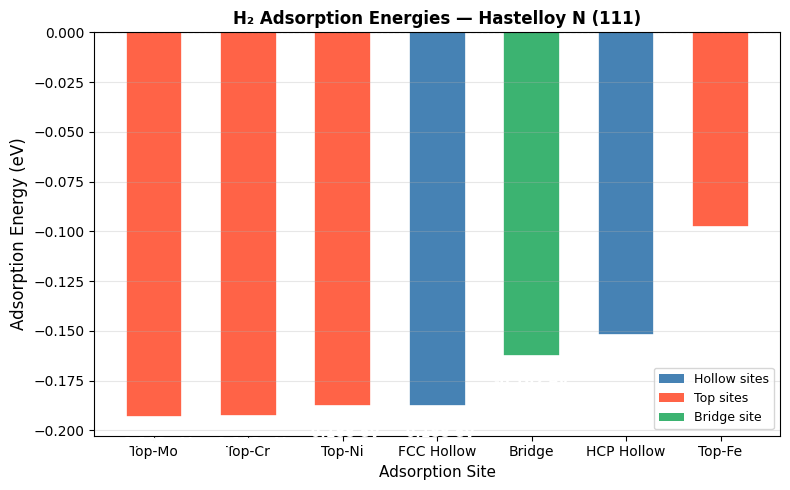

Saved: results/notebook05-adsorption-energy/42_adsorption_energies.png


In [16]:
# ─────────────────────────────────────────────────────────────
# Bar chart: E_ads for each site
# Color coding: hollow sites (blue), top sites (red), bridge (green)
# ─────────────────────────────────────────────────────────────

if not e_ads:
    print('⚠ No adsorption energies available yet. Run jobs first.')
else:
    fig, ax = plt.subplots(figsize=(8, 5))

    site_order = sorted(e_ads, key=e_ads.get)  # sorted most to least stable
    labels     = [SITE_LABELS[s] for s in site_order]
    values     = [e_ads[s] for s in site_order]

    colors = []
    for s in site_order:
        if 'hollow' in s: colors.append('steelblue')
        elif 'top'   in s: colors.append('tomato')
        else:              colors.append('mediumseagreen')

    bars = ax.bar(labels, values, color=colors, edgecolor='white',
                  linewidth=1.2, width=0.6)

    # Annotate each bar with value
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, val - 0.01,
                f'{val:.3f} eV', ha='center', va='top', fontsize=10, color='white', fontweight='bold')

    ax.axhline(0, color='black', lw=0.8, ls='--', alpha=0.5)
    ax.set_ylabel('Adsorption Energy (eV)', fontsize=12)
    ax.set_title('H₂ Adsorption Energies — Hastelloy N (111)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Adsorption Site', fontsize=11)

    # Legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='steelblue', label='Hollow sites'),
        Patch(facecolor='tomato',    label='Top sites'),
        Patch(facecolor='mediumseagreen', label='Bridge site'),
    ]
    ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig('results/notebook05-adsorption-energy/42_adsorption_energies.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: results/notebook05-adsorption-energy/42_adsorption_energies.png')

### 3.10 — Save Best Site Structure for Notebook 06

In [17]:
# ─────────────────────────────────────────────────────────────
# Copy the most stable adsorption configuration
# This becomes the NEB initial state in Notebook 06
# ─────────────────────────────────────────────────────────────
import shutil

if not e_ads:
    print('⚠ Run jobs and compute E_ads first.')
else:
    best_relaxed = f'structures/notebook05-adsorption-energy/42/ads_{best_site}_relaxed.lammps'
    best_output  = 'structures/notebook05-adsorption-energy/42/best_adsorption_site.lammps'

    if os.path.exists(best_relaxed):
        shutil.copy(best_relaxed, best_output)
        print(f'Best site         : {SITE_LABELS[best_site]}')
        print(f'E_ads             : {best_eads:.4f} eV')
        print(f'Source            : {best_relaxed}')
        print(f'Saved as          : {best_output}')
        print(f'→ Use this file as the NEB initial state in Notebook 06')
    else:
        print(f'⚠ Relaxed structure not found: {best_relaxed}')

Best site         : Top-Mo
E_ads             : -0.1931 eV
Source            : structures/notebook05-adsorption-energy/42/ads_top_mo_relaxed.lammps
Saved as          : structures/notebook05-adsorption-energy/42/best_adsorption_site.lammps
→ Use this file as the NEB initial state in Notebook 06


### 3.11 — Decision Cell

In [18]:
# ─────────────────────────────────────────────────────────────
# All checks must pass before Notebook 06
# ─────────────────────────────────────────────────────────────

print('=' * 62)
print('  NOTEBOOK 05 — FINAL DECISION')
print('=' * 62)

checks = [
    ('Clean slab from Notebook 04 exists',
     os.path.exists(SLAB_RELAXED)),
    ('H₂ gas energy computed',
     'h2_gas' in energies),
    ('All 5 site energies computed',
     all(s in energies for s in SITE_COORDS_FILTERED)),
    ('All E_ads are negative (exothermic binding)',
     bool(e_ads) and all(v < 0 for v in e_ads.values())),
    ('Best site structure saved for Notebook 06',
     os.path.exists('structures/notebook05-adsorption-energy/42/best_adsorption_site.lammps')),
]

all_pass = True
for label, ok in checks:
    print(f'  {"✓" if ok else "✗"} {label}')
    if not ok:
        all_pass = False

print()
if all_pass and e_ads:
    print('  ✅ ALL CHECKS PASSED')
    print(f'  → Proceed to Notebook 06 (H₂ Dissociation NEB)')
    print(f'  → NEB initial state : structures/notebook05-adsorption-energy/42/best_adsorption_site.lammps')
    print(f'  → Most stable site  : {SITE_LABELS[best_site]} (E_ads = {best_eads:.4f} eV)')
else:
    print('  ❌ CHECKS FAILED — resolve all ✗ items above')
print('=' * 62)

  NOTEBOOK 05 — FINAL DECISION
  ✓ Clean slab from Notebook 04 exists
  ✓ H₂ gas energy computed
  ✓ All 5 site energies computed
  ✓ All E_ads are negative (exothermic binding)
  ✓ Best site structure saved for Notebook 06

  ✅ ALL CHECKS PASSED
  → Proceed to Notebook 06 (H₂ Dissociation NEB)
  → NEB initial state : structures/notebook05-adsorption-energy/42/best_adsorption_site.lammps
  → Most stable site  : Top-Mo (E_ads = -0.1931 eV)
